### Data Ingestion

In [1]:
import sys
import os
import pandas as pd
import numpy as np

# Allow notebook to access project modules
sys.path.append(os.path.abspath(".."))

from config.config import TRANSACTION_FILE, DATA_DICTIONARY_FILE, PROCESSED_DATA_PATH

pd.set_option("display.max_columns", None)

print("Starting data ingestion and validation...\n")

# ---------------------------------------------------------
# Load dataset
# ---------------------------------------------------------

print("Loading transaction dataset...")

df = pd.read_csv(
    TRANSACTION_FILE,
    low_memory=False
)

print(f"Dataset loaded successfully")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

# ---------------------------------------------------------
# Load data dictionary
# ---------------------------------------------------------

print("\nLoading data dictionary...")

dictionary = pd.read_csv(DATA_DICTIONARY_FILE)

expected_columns = dictionary["Column Name"].str.strip().tolist()
actual_columns = df.columns.tolist()

print(f"Expected columns from dictionary: {len(expected_columns)}")
print(f"Columns in dataset: {len(actual_columns)}")

# ---------------------------------------------------------
# Column validation
# ---------------------------------------------------------

print("\nValidating column names...")

missing_columns = sorted(list(set(expected_columns) - set(actual_columns)))
extra_columns = sorted(list(set(actual_columns) - set(expected_columns)))

if missing_columns:
    print("\nColumns missing from dataset:")
    for col in missing_columns:
        print(f"  - {col}")
else:
    print("No missing columns relative to data dictionary.")

if extra_columns:
    print("\nExtra columns present in dataset (not in dictionary):")
    for col in extra_columns:
        print(f"  - {col}")
else:
    print("No unexpected columns detected.")

# ---------------------------------------------------------
# Timestamp validation
# ---------------------------------------------------------

print("\nValidating timestamp column...")

invalid_timestamps = 0

if "timestamp" in df.columns:

    parsed_timestamp = pd.to_datetime(
        df["timestamp"],
        errors="coerce"
    )

    invalid_timestamps = parsed_timestamp.isna().sum()

    print(f"Invalid timestamp records detected: {invalid_timestamps}")

    if invalid_timestamps > 0:
        df = df.loc[parsed_timestamp.notna()].copy()
        df["timestamp"] = parsed_timestamp.dropna()
        print("Invalid timestamp rows removed")

else:
    print("Timestamp column not found in dataset")

# ---------------------------------------------------------
# Normalize categorical values
# ---------------------------------------------------------

print("\nNormalizing categorical fields...")

categorical_cols = df.select_dtypes(include="object").columns.tolist()

for col in categorical_cols:

    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.lower()
    )

print(f"Categorical columns normalized: {len(categorical_cols)}")

# ---------------------------------------------------------
# Duplicate detection
# ---------------------------------------------------------

print("\nChecking duplicate transactions...")

duplicate_count = 0

if "transaction_id" in df.columns:

    duplicate_count = df.duplicated(subset=["transaction_id"]).sum()

    print(f"Duplicate transaction IDs detected: {duplicate_count}")

    if duplicate_count > 0:
        df = df.drop_duplicates(subset=["transaction_id"])
        print("Duplicate transactions removed")

else:
    print("transaction_id column not found")

# ---------------------------------------------------------
# Missing value analysis
# ---------------------------------------------------------

print("\nCalculating missing value statistics...")

missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

missing_report = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent
})

missing_report = missing_report.sort_values(
    "missing_percent",
    ascending=False
)

# ---------------------------------------------------------
# Basic statistics
# ---------------------------------------------------------

numeric_summary = df.describe().T

# ---------------------------------------------------------
# Save cleaned dataset
# ---------------------------------------------------------

os.makedirs(PROCESSED_DATA_PATH, exist_ok=True)

output_file = os.path.join(
    PROCESSED_DATA_PATH,
    "transactions_cleaned.csv"
)

df.to_csv(output_file, index=False)

# ---------------------------------------------------------
# Final ingestion report
# ---------------------------------------------------------

print("\n==============================")
print("DATA INGESTION SUMMARY REPORT")
print("==============================")

print(f"Rows after ingestion cleaning: {len(df)}")
print(f"Total columns: {len(df.columns)}")
print(f"Duplicate transactions removed: {duplicate_count}")
print(f"Invalid timestamps removed: {invalid_timestamps}")

print("\nTop columns with missing data:")
print(missing_report.head(10))

print("\nNumeric feature summary:")
print(numeric_summary.head())

print(f"\nCleaned dataset saved to:")
print(output_file)

print("\nData ingestion and validation completed successfully.")

Starting data ingestion and validation...

Loading transaction dataset...
Dataset loaded successfully
Rows: 10200
Columns: 26

Loading data dictionary...
Expected columns from dictionary: 20
Columns in dataset: 26

Validating column names...
No missing columns relative to data dictionary.

Extra columns present in dataset (not in dictionary):
  - device_id
  - exchange_rate_src_to_dest
  - ip_address
  - ip_country
  - location_mismatch
  - new_device

Validating timestamp column...
Invalid timestamp records detected: 61
Invalid timestamp rows removed

Normalizing categorical fields...
Categorical columns normalized: 11

Checking duplicate transactions...
Duplicate transaction IDs detected: 199
Duplicate transactions removed

Calculating missing value statistics...

DATA INGESTION SUMMARY REPORT
Rows after ingestion cleaning: 9940
Total columns: 26
Duplicate transactions removed: 199
Invalid timestamps removed: 61

Top columns with missing data:
                    missing_count  missi

### Data Cleaning and Processing

In [2]:
import sys
import os
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import ExtraTreesRegressor, ExtraTreesClassifier

# Allow notebook to access project modules
sys.path.append(os.path.abspath(".."))

from config.config import INGESTION_OUTPUT_FILE, PREPARED_DATA_FILE

pd.set_option("display.max_columns", None)

print("Starting data cleaning and preparation...\n")

# ---------------------------------------------------------
# Load dataset from ingestion step
# ---------------------------------------------------------

print("Loading ingestion output dataset...")

df = pd.read_csv(INGESTION_OUTPUT_FILE)

# Normalize categorical values and treat 'unknown' as missing

for col in df.select_dtypes(include="object").columns:

    df[col] = df[col].astype(str).str.strip().str.lower()

    df[col] = df[col].replace(
        ["unknown", "na", "n/a", ""],
        np.nan
    )

print("Dataset loaded successfully")
print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")


# ---------------------------------------------------------
# Drop rows with critical identifiers missing
# ---------------------------------------------------------

print("\nChecking critical identifiers...")

critical_cols = ["transaction_id", "timestamp"]

rows_before = len(df)

df = df.dropna(subset=critical_cols)

rows_after = len(df)

print(f"Rows removed due to missing identifiers: {rows_before - rows_after}")


# ---------------------------------------------------------
# Timestamp parsing and feature extraction
# ---------------------------------------------------------

print("\nParsing timestamp column...")

parsed_timestamp = pd.to_datetime(
    df["timestamp"],
    errors="coerce",
    utc=True
)

invalid_rows = parsed_timestamp.isna().sum()

print(f"Timestamp parsing failures: {invalid_rows}")

df = df.loc[parsed_timestamp.notna()].copy()

df["timestamp"] = parsed_timestamp.dropna()

# Feature engineering

df["txn_hour"] = df["timestamp"].dt.hour
df["txn_day_of_week"] = df["timestamp"].dt.dayofweek
df["txn_day"] = df["timestamp"].dt.day
df["txn_month"] = df["timestamp"].dt.month

print("Timestamp features created")


# ---------------------------------------------------------
# Detect column types
# ---------------------------------------------------------

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include="object").columns.tolist()

print(f"\nNumeric columns detected: {len(numeric_cols)}")
print(f"Categorical columns detected: {len(categorical_cols)}")


# ---------------------------------------------------------
# Detect datatype anomalies
# ---------------------------------------------------------

print("\nChecking numeric columns for unexpected values...")

datatype_issues = {}

for col in numeric_cols:

    invalid_entries = df[col].apply(lambda x: isinstance(x, str)).sum()

    if invalid_entries > 0:
        datatype_issues[col] = invalid_entries

if datatype_issues:

    print("Datatype issues detected:")

    for col, count in datatype_issues.items():
        print(f"{col} : {count} suspicious entries")

else:
    print("No datatype inconsistencies detected.")


# ---------------------------------------------------------
# Prepare a copy for ML-based imputation
# ---------------------------------------------------------

print("\nPreparing temporary dataset for ML imputation...")

model_df = df.copy()

# remove timestamp and identifier columns
columns_to_exclude = ["timestamp", "transaction_id"]

model_df = model_df.drop(
    columns=[c for c in columns_to_exclude if c in model_df.columns]
)


# ---------------------------------------------------------
# Encode categorical columns for ML
# ---------------------------------------------------------

label_encoders = {}

for col in categorical_cols:

    if col in model_df.columns:

        le = LabelEncoder()

        model_df[col] = model_df[col].astype(str)

        model_df[col] = le.fit_transform(model_df[col])

        label_encoders[col] = le


# ---------------------------------------------------------
# ML-based imputation for numeric columns
# ---------------------------------------------------------

print("\nRunning ML-based numeric imputation...")

numeric_imputed = []

for col in numeric_cols:

    if col not in model_df.columns:
        continue

    if df[col].isna().sum() == 0:
        continue

    train_df = model_df[model_df[col].notna()]
    test_df = model_df[model_df[col].isna()]

    if len(test_df) == 0:
        continue

    X_train = train_df.drop(columns=[col])
    y_train = train_df[col]

    X_test = test_df.drop(columns=[col])

    model = ExtraTreesRegressor(
        n_estimators=50,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    df.loc[df[col].isna(), col] = preds

    numeric_imputed.append(col)

print(f"Numeric columns imputed: {numeric_imputed}")


# ---------------------------------------------------------
# ML-based imputation for categorical columns
# ---------------------------------------------------------

print("\nRunning ML-based categorical imputation...")

categorical_imputed = []

for col in categorical_cols:

    if col not in model_df.columns:
        continue

    if df[col].isna().sum() == 0:
        continue

    train_df = model_df[model_df[col].notna()]
    test_df = model_df[model_df[col].isna()]

    if len(test_df) == 0:
        continue

    X_train = train_df.drop(columns=[col])
    y_train = train_df[col]

    X_test = test_df.drop(columns=[col])

    model = ExtraTreesClassifier(
        n_estimators=50,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    decoded = label_encoders[col].inverse_transform(preds)

    df.loc[df[col].isna(), col] = decoded

    categorical_imputed.append(col)

print(f"Categorical columns imputed: {categorical_imputed}")


# ---------------------------------------------------------
# Final validation
# ---------------------------------------------------------

remaining_missing = df.isna().sum().sum()

print("\nRemaining missing values:", remaining_missing)

if remaining_missing == 0:
    print("Dataset ready for modeling.")
else:
    print("Some missing values remain and should be reviewed.")


# ---------------------------------------------------------
# Fraud distribution check
# ---------------------------------------------------------

if "is_fraud" in df.columns:

    print("\nFraud class distribution:")

    print(df["is_fraud"].value_counts())

    fraud_rate = df["is_fraud"].mean()

    print(f"Fraud rate: {fraud_rate:.4f}")


# ---------------------------------------------------------
# Save prepared dataset
# ---------------------------------------------------------

os.makedirs(os.path.dirname(PREPARED_DATA_FILE), exist_ok=True)

df.to_csv(PREPARED_DATA_FILE, index=False)

print("\nPrepared dataset saved to:")
print(PREPARED_DATA_FILE)

print("\nData cleaning and preparation completed successfully.")

Starting data cleaning and preparation...

Loading ingestion output dataset...
Dataset loaded successfully
Rows: 9940 | Columns: 26

Checking critical identifiers...
Rows removed due to missing identifiers: 0

Parsing timestamp column...
Timestamp parsing failures: 0
Timestamp features created

Numeric columns detected: 16
Categorical columns detected: 11

Checking numeric columns for unexpected values...
No datatype inconsistencies detected.

Preparing temporary dataset for ML imputation...

Running ML-based numeric imputation...
Numeric columns imputed: ['amount_usd', 'fee', 'device_trust_score']

Running ML-based categorical imputation...
Categorical columns imputed: []

Remaining missing values: 130
Some missing values remain and should be reviewed.

Fraud class distribution:
is_fraud
0    9747
1     193
Name: count, dtype: int64
Fraud rate: 0.0194

Prepared dataset saved to:
C:\Users\dauda.agbonoga\Documents\error\nova-pay-fraud-prototype\data\processed\transactions_prepared.csv



### Exploratory Data Analysis

Loading prepared dataset for EDA...
Dataset loaded
(9940, 30)
Fraud vs Non Fraud Counts:
is_fraud
0    9747
1     193
Name: count, dtype: int64


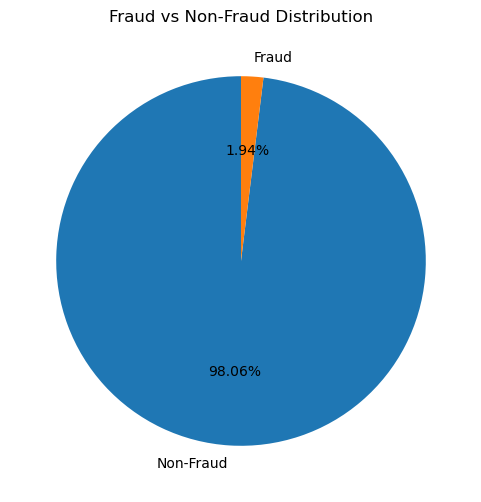


Fraud rate: 0.0194


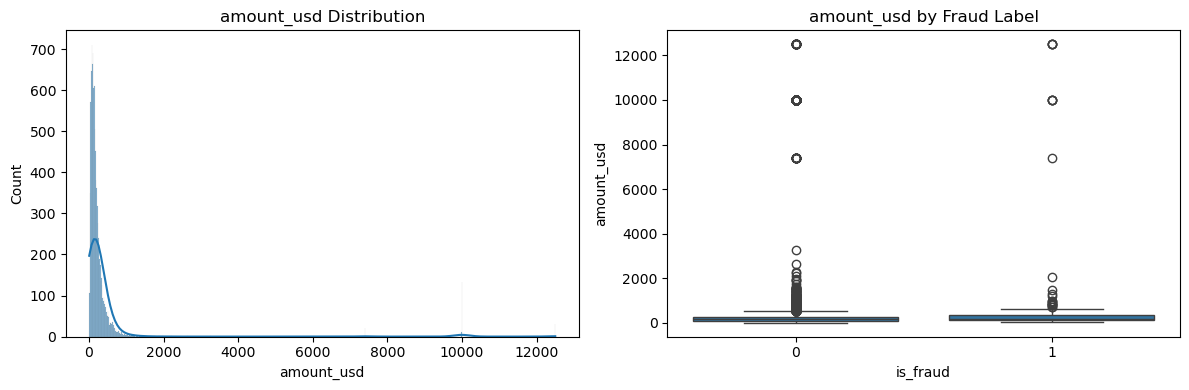

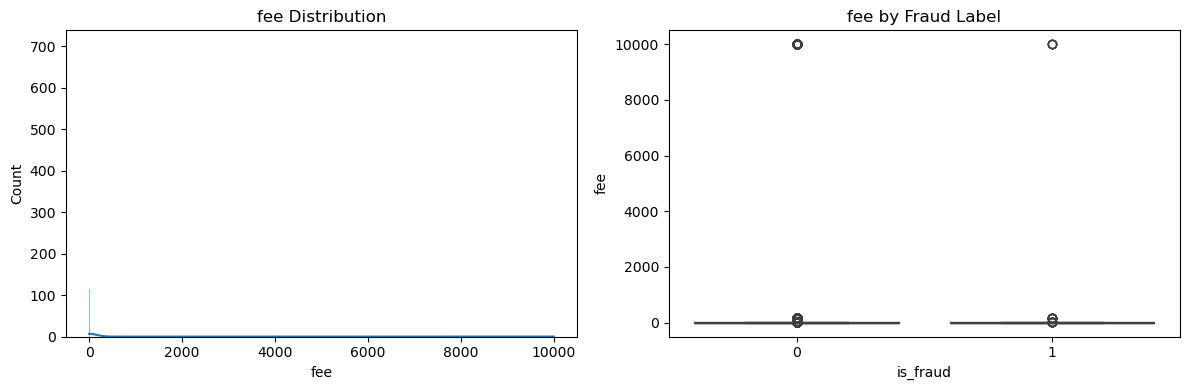

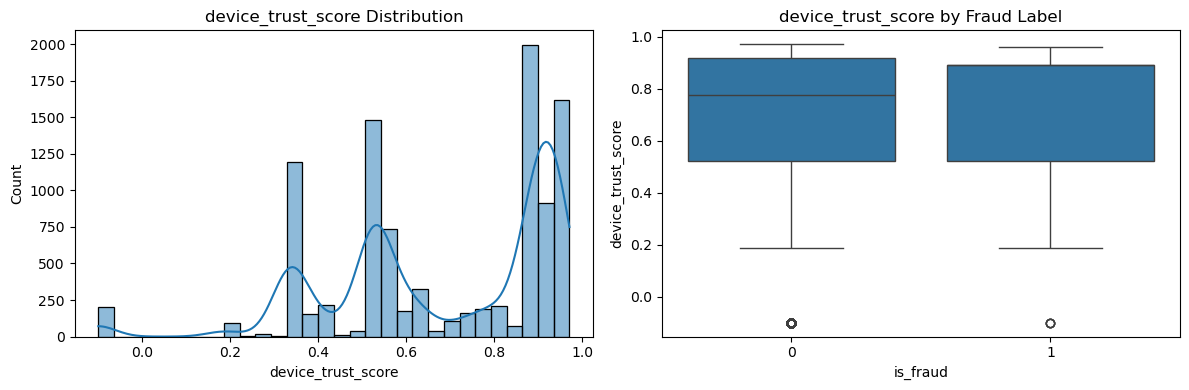

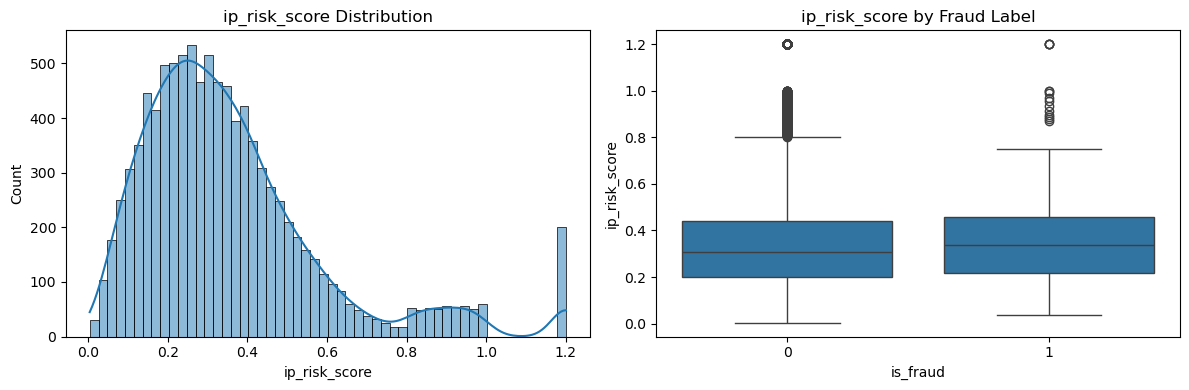


channel fraud statistics
         count  fraud_rate
channel                   
web       3083    0.026273
mobile    5841    0.016778
atm        896    0.014509
mobille     59    0.000000
weeb        24    0.000000


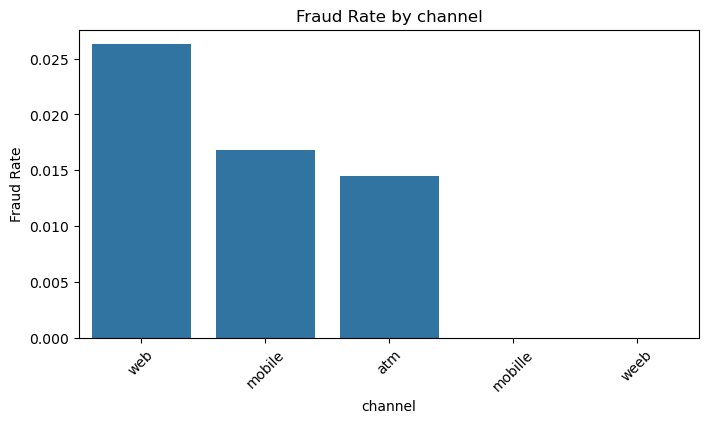


kyc_tier fraud statistics
          count  fraud_rate
kyc_tier                   
low         487    0.034908
standard   7409    0.021730
enhanced   1716    0.004079


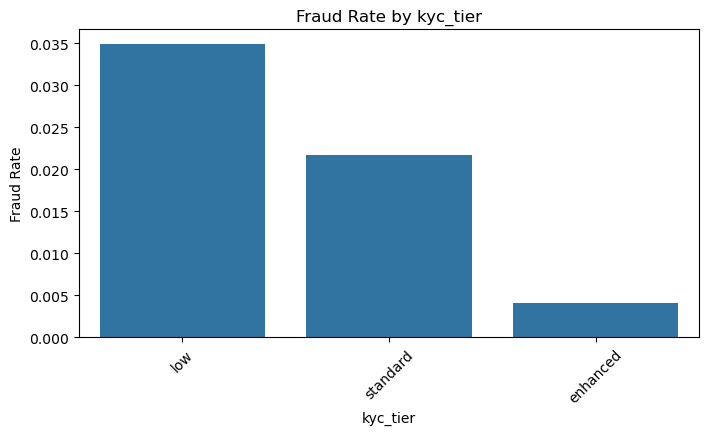


home_country fraud statistics
              count  fraud_rate
home_country                   
UK             1770    0.048588
CA              981    0.019368
US             7157    0.012156


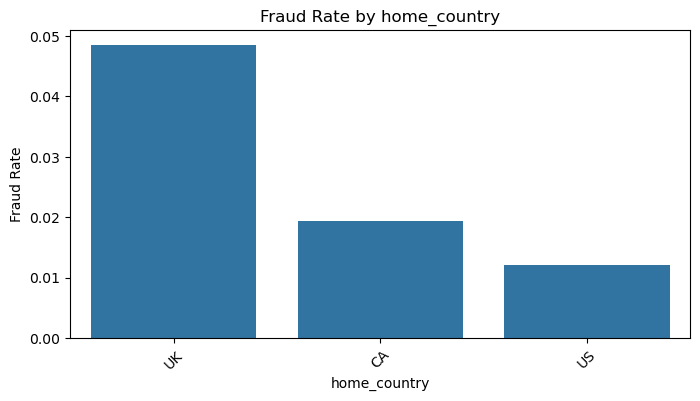

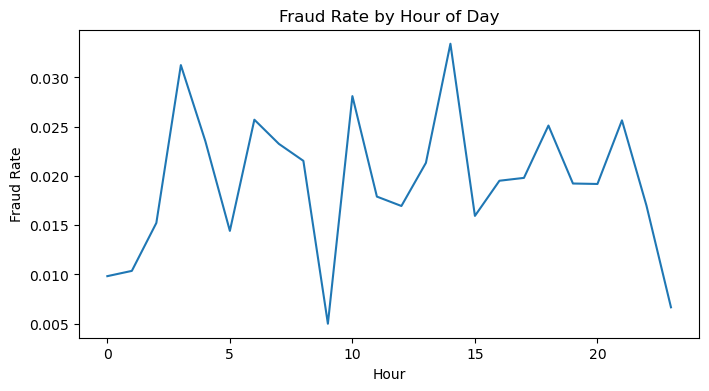

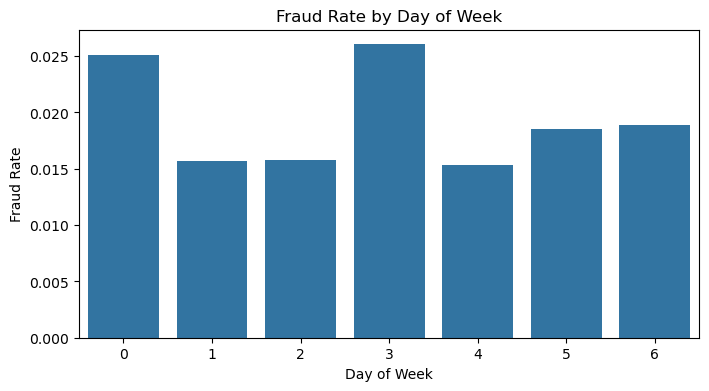

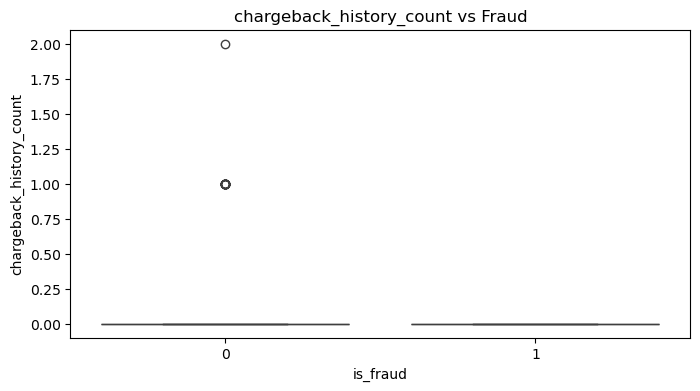

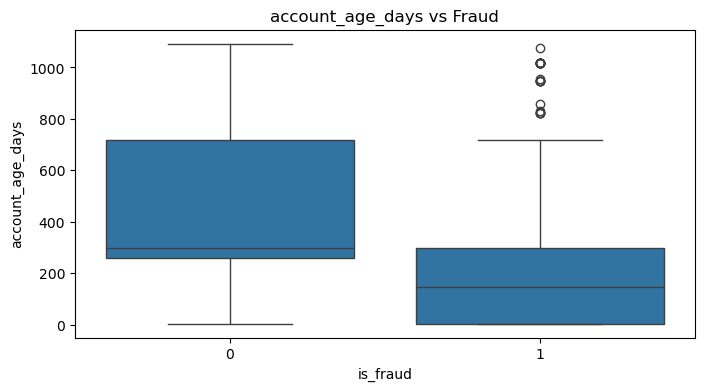

EDA summary saved.


In [3]:
# ===============================
# Exploratory Data Analysis
# ===============================

import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath(".."))

from config.config import PREPARED_DATA_FILE, EDA_OUTPUT_PATH, REPORTS_PATH

print("Loading prepared dataset for EDA...")

df = pd.read_csv(PREPARED_DATA_FILE)

print("Dataset loaded")
print(df.shape)

# ------------------------------------------------
# Normalize categorical values
# ------------------------------------------------

df["channel"] = df["channel"].str.lower().str.strip()
df["kyc_tier"] = df["kyc_tier"].str.lower().str.strip()
df["home_country"] = df["home_country"].str.upper().str.strip()

# Fix typos in KYC tier
kyc_corrections = {
    "standrd": "standard",
    "enhancd": "enhanced"
}

df["kyc_tier"] = df["kyc_tier"].replace(kyc_corrections)

# Fix typos in channel
channel_corrections = {
    "weeb": "web"
}

df["channel"] = df["channel"].replace(kyc_corrections)

TARGET_COL = "is_fraud"

numeric_cols = [
    "amount_usd",
    "fee",
    "device_trust_score",
    "ip_risk_score"
]

categorical_cols = [
    "channel",
    "kyc_tier",
    "home_country"
]

customer_behavior_cols = [
    "chargeback_history_count",
    "account_age_days"
]

# --------------------------------
# 1 Class balance
# --------------------------------

fraud_counts = df[TARGET_COL].value_counts()

print("Fraud vs Non Fraud Counts:")
print(fraud_counts)

plt.figure(figsize=(6,6))

plt.pie(
    fraud_counts,
    labels=["Non-Fraud","Fraud"],
    autopct="%1.2f%%",
    startangle=90
)

plt.title("Fraud vs Non-Fraud Distribution")
plt.show()

fraud_rate = fraud_counts[1] / fraud_counts.sum()

print(f"\nFraud rate: {fraud_rate:.4f}")

# --------------------------------
# 2 Numerical distributions
# --------------------------------

for col in numeric_cols:

    fig, axes = plt.subplots(1,2, figsize=(12,4))

    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f"{col} Distribution")

    sns.boxplot(
        x=TARGET_COL,
        y=col,
        data=df,
        ax=axes[1]
    )

    axes[1].set_title(f"{col} by Fraud Label")

    plt.tight_layout()
    plt.show()

# --------------------------------
# 3 Categorical fraud rate
# --------------------------------

for col in categorical_cols:

    pivot = (
        df.groupby(col)[TARGET_COL]
        .agg(["count","mean"])
        .rename(columns={"mean":"fraud_rate"})
        .sort_values("fraud_rate", ascending=False)
    )

    print(f"\n{col} fraud statistics")
    print(pivot)

    plt.figure(figsize=(8,4))

    sns.barplot(
        x=pivot.index,
        y=pivot["fraud_rate"]
    )

    plt.title(f"Fraud Rate by {col}")
    plt.ylabel("Fraud Rate")

    plt.xticks(rotation=45)

    plt.show()

# --------------------------------
# 4 Time patterns
# --------------------------------

hourly_fraud = df.groupby("txn_hour")[TARGET_COL].mean()
daily_fraud = df.groupby("txn_day_of_week")[TARGET_COL].mean()

plt.figure(figsize=(8,4))

sns.lineplot(x=hourly_fraud.index, y=hourly_fraud.values)

plt.title("Fraud Rate by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate")

plt.show()

plt.figure(figsize=(8,4))

sns.barplot(x=daily_fraud.index, y=daily_fraud.values)

plt.title("Fraud Rate by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Fraud Rate")

plt.show()

# --------------------------------
# 5 Customer behavior analysis
# --------------------------------

for col in customer_behavior_cols:

    plt.figure(figsize=(8,4))

    sns.boxplot(
        x=TARGET_COL,
        y=col,
        data=df
    )

    plt.title(f"{col} vs Fraud")

    plt.show()

# ------------------------------------------------
# Export results
# ------------------------------------------------

os.makedirs(EDA_OUTPUT_PATH, exist_ok=True)
os.makedirs(REPORTS_PATH, exist_ok=True)

fraud_channel = df.groupby("channel")["is_fraud"].agg(["count","mean"])

fraud_channel.to_csv(
    os.path.join(EDA_OUTPUT_PATH, "fraud_by_channel.csv")
)

summary = f"""
EDA SUMMARY
-----------

Total transactions: {len(df)}

Fraud count: {df['is_fraud'].sum()}
Fraud rate: {df['is_fraud'].mean():.4f}

Key observations:
- Review numeric distribution plots
- Review categorical fraud rate plots
- Review time based fraud plots
"""

with open(os.path.join(REPORTS_PATH, "eda_summary.txt"), "w") as f:
    f.write(summary)

print("EDA summary saved.")

### Feature Engineering

In [4]:
# ============================================
# Feature Engineering
# ============================================

import sys
import os
import pandas as pd
import numpy as np

sys.path.append(os.path.abspath(".."))

from config.config import PREPARED_DATA_FILE, FEATURE_DATA_FILE, RANDOM_SEED

print("Loading dataset for feature engineering...")

df = pd.read_csv(PREPARED_DATA_FILE, low_memory=False)

print("Dataset loaded")
print("Shape:", df.shape)

TARGET_COL = "is_fraud"


# ------------------------------------------------
# Ensure timestamp is parsed correctly
# ------------------------------------------------

print("\nParsing timestamps...")

df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")

invalid_timestamps = df["timestamp"].isna().sum()

if invalid_timestamps > 0:
    print(f"Warning: {invalid_timestamps} rows have invalid timestamps")

df = df.dropna(subset=["timestamp"])


# ------------------------------------------------
# Ensure numeric columns are numeric
# ------------------------------------------------

numeric_cols = [
    "amount_usd",
    "fee",
    "exchange_rate_src_to_dest",
    "ip_risk_score",
    "account_age_days",
    "device_trust_score",
    "chargeback_history_count",
    "risk_score_internal",
    "txn_velocity_1h",
    "txn_velocity_24h",
    "corridor_risk"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


# ------------------------------------------------
# 1 Time Based Features
# ------------------------------------------------

print("\nCreating time based features...")

df["txn_hour"] = df["timestamp"].dt.hour
df["txn_day_of_week"] = df["timestamp"].dt.dayofweek
df["txn_day"] = df["timestamp"].dt.day
df["txn_month"] = df["timestamp"].dt.month
df["is_weekend"] = df["txn_day_of_week"].isin([5, 6]).astype(int)


# ------------------------------------------------
# 2 Derived Numerical Features
# ------------------------------------------------

print("Creating derived numeric features...")

df["fee_pct"] = df["fee"] / (df["amount_usd"] + 1e-6)
df["log_amount"] = np.log1p(df["amount_usd"])


# ------------------------------------------------
# 3 Customer Velocity Features
# ------------------------------------------------

print("Creating customer velocity features...")

df = df.sort_values(["customer_id", "timestamp"]).reset_index(drop=True)

txn_24h_list = []
txn_7d_list = []
avg_7d_list = []

for idx, row in df.iterrows():

    cid = row["customer_id"]
    ts = row["timestamp"]

    cust_df = df[df["customer_id"] == cid]

    past_24h = cust_df[
        (cust_df["timestamp"] <= ts) &
        (cust_df["timestamp"] >= ts - pd.Timedelta(hours=24))
    ]

    past_7d = cust_df[
        (cust_df["timestamp"] <= ts) &
        (cust_df["timestamp"] >= ts - pd.Timedelta(days=7))
    ]

    txn_24h_list.append(len(past_24h))
    txn_7d_list.append(len(past_7d))
    avg_7d_list.append(past_7d["amount_usd"].mean())

df["txn_count_24h"] = txn_24h_list
df["txn_count_7d"] = txn_7d_list
df["avg_amount_7d"] = avg_7d_list


# ------------------------------------------------
# 4 Device and IP Behaviour Features
# ------------------------------------------------

print("Creating device and IP behavior features...")

device_list = []
ip_list = []

for idx, row in df.iterrows():

    cid = row["customer_id"]
    ts = row["timestamp"]

    cust_df = df[df["customer_id"] == cid]

    past_30d = cust_df[
        (cust_df["timestamp"] <= ts) &
        (cust_df["timestamp"] >= ts - pd.Timedelta(days=30))
    ]

    device_list.append(past_30d["device_id"].nunique())
    ip_list.append(past_30d["ip_address"].nunique())

df["distinct_devices_30d"] = device_list
df["distinct_ips_30d"] = ip_list


# ------------------------------------------------
# 5 Replace NaNs from rolling calculations
# ------------------------------------------------

rolling_cols = [
    "txn_count_24h",
    "txn_count_7d",
    "avg_amount_7d",
    "distinct_devices_30d",
    "distinct_ips_30d"
]

df[rolling_cols] = df[rolling_cols].fillna(0)


# ------------------------------------------------
# 6 One Hot Encoding for categorical variables
# ------------------------------------------------

print("Encoding categorical features...")

categorical_cols = [
    "channel",
    "kyc_tier",
    "home_country",
    "source_currency",
    "dest_currency"
]

existing_cat_cols = [c for c in categorical_cols if c in df.columns]

df = pd.get_dummies(
    df,
    columns=existing_cat_cols,
    drop_first=True
)


# ------------------------------------------------
# 7 Remove leakage columns
# ------------------------------------------------

print("Removing leakage columns...")

drop_cols = [
    "transaction_id",
    "device_id",
    "ip_address",
    "customer_id"
]

existing_drop = [c for c in drop_cols if c in df.columns]

df = df.drop(columns=existing_drop)


# ------------------------------------------------
# 8 Remove constant columns
# ------------------------------------------------

print("Removing constant columns...")

constant_cols = [c for c in df.columns if df[c].nunique() <= 1]

df = df.drop(columns=constant_cols)

print("Removed constant columns:", constant_cols)


# ------------------------------------------------
# 9 Final dataset validation
# ------------------------------------------------

print("\nFinal dataset validation")

print("Final shape:", df.shape)

missing_values = df.isnull().sum().sum()

if missing_values == 0:
    print("No missing values remaining")
else:
    print(f"Warning: {missing_values} missing values remain")


# ------------------------------------------------
# Save feature dataset
# ------------------------------------------------

os.makedirs(os.path.dirname(FEATURE_DATA_FILE), exist_ok=True)

df.to_csv(FEATURE_DATA_FILE, index=False)

print("\nFeature engineered dataset saved to:")
print(FEATURE_DATA_FILE)

Loading dataset for feature engineering...
Dataset loaded
Shape: (9940, 30)

Parsing timestamps...

Creating time based features...
Creating derived numeric features...
Creating customer velocity features...
Creating device and IP behavior features...
Encoding categorical features...
Removing leakage columns...
Removing constant columns...
Removed constant columns: []

Final dataset validation
Final shape: (9940, 49)

Feature engineered dataset saved to:
C:\Users\dauda.agbonoga\Documents\error\nova-pay-fraud-prototype\data\processed\transactions_feature_engineered.csv


| Feature              | Why It Helps                      |
| -------------------- | --------------------------------- |
| txn_hour             | Fraud occurs more at odd hours    |
| txn_day_of_week      | Weekend fraud patterns            |
| txn_count_24h        | High velocity suspicious activity |
| txn_count_7d         | Burst fraud patterns              |
| avg_amount_7d        | Detect unusual spending           |
| distinct_devices_30d | Multiple device access            |
| distinct_ips_30d     | VPN / proxy switching             |
| fee_pct              | Abnormal fee patterns             |
| log_amount           | Reduces skew                      |


### Modelling and Evaluation

In [3]:
# ============================================
# Modeling and Evaluation
# ============================================

import sys
import os
import pandas as pd
import numpy as np
import joblib
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

from sklearn.model_selection import RandomizedSearchCV


# ============================================
# Import config
# ============================================

sys.path.append(os.path.abspath(".."))

from config.config import (
    FEATURE_DATA_FILE,
    BEST_MODEL_FILE,
    MODEL_METRICS_FILE,
    RANDOM_SEED
)


# ============================================
# Load dataset
# ============================================

print("Loading feature engineered dataset...")

df = pd.read_csv(FEATURE_DATA_FILE, low_memory=False)

print("Dataset shape:", df.shape)

TARGET_COL = "is_fraud"


# ============================================
# Fix datatypes
# ============================================

print("\nFixing datatypes...")

if "timestamp" in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

# force numeric conversion where possible
for col in df.columns:
    if col not in ["timestamp", TARGET_COL]:
        df[col] = pd.to_numeric(df[col], errors="ignore")


# ============================================
# Detect categorical columns properly
# ============================================

print("\nDetecting categorical columns...")

categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Categorical columns:", categorical_cols)


# ============================================
# One-hot encode categoricals
# ============================================

if len(categorical_cols) > 0:

    print("Applying one-hot encoding...")

    df = pd.get_dummies(
        df,
        columns=categorical_cols,
        drop_first=False
    )

print("Dataset shape after encoding:", df.shape)


# ============================================
# Clean feature names (LightGBM requirement)
# ============================================

print("\nCleaning feature names...")

df.columns = [
    re.sub('[^A-Za-z0-9_]+', '_', col)
    for col in df.columns
]


# ============================================
# Dataset split
# ============================================

print("\nCreating dataset split...")

if "timestamp" in df.columns:

    print("Using time based split")

    df = df.sort_values("timestamp")

    train_size = int(len(df) * 0.70)
    val_size = int(len(df) * 0.85)

    train = df.iloc[:train_size]
    val = df.iloc[train_size:val_size]
    test = df.iloc[val_size:]

    drop_cols = ["timestamp"]

else:

    print("Timestamp not found → using random split")

    train, temp = train_test_split(
        df,
        test_size=0.30,
        random_state=RANDOM_SEED,
        stratify=df[TARGET_COL]
    )

    val, test = train_test_split(
        temp,
        test_size=0.50,
        random_state=RANDOM_SEED,
        stratify=temp[TARGET_COL]
    )

    drop_cols = []

print("Train:", train.shape)
print("Validation:", val.shape)
print("Test:", test.shape)


# ============================================
# Feature / target split
# ============================================

X_train = train.drop(columns=[TARGET_COL] + drop_cols, errors="ignore")
y_train = train[TARGET_COL]

X_val = val.drop(columns=[TARGET_COL] + drop_cols, errors="ignore")
y_val = val[TARGET_COL]

X_test = test.drop(columns=[TARGET_COL] + drop_cols, errors="ignore")
y_test = test[TARGET_COL]


# ============================================
# Feature alignment
# ============================================

print("\nAligning feature columns...")

X_train, X_val = X_train.align(X_val, join="left", axis=1, fill_value=0)
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

print("Training features:", X_train.shape)


# ============================================
# Scale features for Logistic Regression
# ============================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


# ============================================
# Train baseline models
# ============================================

print("\nTraining baseline models...")

sample_frac = 0.30

sample_idx = X_train.sample(frac=sample_frac, random_state=RANDOM_SEED).index

X_sample = X_train.loc[sample_idx]
y_sample = y_train.loc[sample_idx]

X_sample_scaled = scaler.transform(X_sample)

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=3000, class_weight="balanced"),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=150,
            class_weight="balanced",
            random_state=RANDOM_SEED
        ),

    "XGBoost":
        xgb.XGBClassifier(
            eval_metric="logloss",
            scale_pos_weight=10,
            random_state=RANDOM_SEED
        ),

    "LightGBM":
        lgb.LGBMClassifier(
            class_weight="balanced",
            random_state=RANDOM_SEED
        ),

    "CatBoost":
        CatBoostClassifier(
            verbose=0,
            random_state=RANDOM_SEED
        )
}

results = []

for name, model in models.items():

    print(f"\nTraining {name}")

    if name == "Logistic Regression":
        model.fit(X_sample_scaled, y_sample)
        preds = model.predict(X_val_scaled)
        probs = model.predict_proba(X_val_scaled)[:, 1]

    else:
        model.fit(X_sample, y_sample)
        preds = model.predict(X_val)
        probs = model.predict_proba(X_val)[:, 1]

    roc = roc_auc_score(y_val, probs)
    pr = average_precision_score(y_val, probs)
    f1 = f1_score(y_val, preds)

    results.append({
        "model": name,
        "roc_auc": roc,
        "pr_auc": pr,
        "f1": f1
    })


results_df = pd.DataFrame(results)

print("\nModel comparison")
print(results_df)


# ============================================
# Best model selection
# ============================================

best_model_name = results_df.sort_values(
    "pr_auc",
    ascending=False
).iloc[0]["model"]

print("\nBest baseline model:", best_model_name)

best_model = models[best_model_name]


# ============================================
# Hyperparameter tuning
# ============================================

print("\nRunning hyperparameter tuning...")

if best_model_name in ["XGBoost", "LightGBM"]:

    param_grid = {
        "n_estimators": [200, 300, 400],
        "max_depth": [4, 6, 8],
        "learning_rate": [0.01, 0.05, 0.1]
    }

elif best_model_name == "Random Forest":

    param_grid = {
        "n_estimators": [200, 300, 400],
        "max_depth": [None, 10, 20]
    }

elif best_model_name == "Logistic Regression":

    param_grid = {
        "C": [0.01, 0.1, 1, 10]
    }

else:

    param_grid = {}

if len(param_grid) > 0:

    search = RandomizedSearchCV(
        best_model,
        param_distributions=param_grid,
        n_iter=10,
        scoring="average_precision",
        cv=3,
        random_state=RANDOM_SEED,
        n_jobs=-1
    )

    if best_model_name == "Logistic Regression":
        search.fit(X_train_scaled, y_train)
    else:
        search.fit(X_train, y_train)

    best_model = search.best_estimator_

    print("Best parameters:", search.best_params_)


# ============================================
# Final evaluation
# ============================================

print("\nEvaluating final model...")

if best_model_name == "Logistic Regression":
    preds = best_model.predict(X_test_scaled)
    probs = best_model.predict_proba(X_test_scaled)[:, 1]
else:
    preds = best_model.predict(X_test)
    probs = best_model.predict_proba(X_test)[:, 1]

metrics = {

    "ROC_AUC": roc_auc_score(y_test, probs),
    "PR_AUC": average_precision_score(y_test, probs),
    "Precision": precision_score(y_test, preds),
    "Recall": recall_score(y_test, preds),
    "F1": f1_score(y_test, preds)
}

print("\nFinal Model Performance")

for k, v in metrics.items():
    print(f"{k}: {v:.4f}")


# ============================================
# Save trained model
# ============================================

os.makedirs(os.path.dirname(BEST_MODEL_FILE), exist_ok=True)

joblib.dump(best_model, BEST_MODEL_FILE)

print("\nModel saved to:", BEST_MODEL_FILE)


# ============================================
# Save metrics
# ============================================

metrics_df = pd.DataFrame([metrics])

os.makedirs(os.path.dirname(MODEL_METRICS_FILE), exist_ok=True)

metrics_df.to_csv(MODEL_METRICS_FILE, index=False)

print("Metrics exported to:", MODEL_METRICS_FILE)

Loading feature engineered dataset...
Dataset shape: (9940, 49)

Fixing datatypes...

Detecting categorical columns...
Categorical columns: ['amount_src', 'ip_country']
Applying one-hot encoding...
Dataset shape after encoding: (9940, 8803)

Cleaning feature names...

Creating dataset split...
Using time based split


C:\Users\dauda.agbonoga\AppData\Local\Temp\ipykernel_14976\3893485600.py:71: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")


Train: (6958, 8803)
Validation: (1491, 8803)
Test: (1491, 8803)

Aligning feature columns...
Training features: (6958, 8801)

Training baseline models...

Training Logistic Regression

Training Random Forest

Training XGBoost

Training LightGBM
[LightGBM] [Info] Number of positive: 38, number of negative: 2049
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001403 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1978
[LightGBM] [Info] Number of data points in the train set: 2087, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

Training CatBoost

Model comparison
                 model   roc_auc    pr_auc        f1
0  Logistic Regression  0.684038  0.0

c:\Users\dauda.agbonoga\anaconda3\envs\nova-pay-env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



Final Model Performance
ROC_AUC: 0.7188
PR_AUC: 0.0714
Precision: 0.0000
Recall: 0.0000
F1: 0.0000

Model saved to: C:\Users\dauda.agbonoga\Documents\error\nova-pay-fraud-prototype\models\best_fraud_model.pkl
Metrics exported to: C:\Users\dauda.agbonoga\Documents\error\nova-pay-fraud-prototype\reports\model_metrics.csv
